# Ranking metrics

Code for the book:

[Imbalanced Data: Myths, Mistakes and Modern Solutions](https://www.trainindata.com/p/imbalanced-data-myths-mistakes-solutions-book)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

from matplotlib.colors import LinearSegmentedColormap

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_curve,
    roc_auc_score,
)

from imblearn.datasets import fetch_datasets

In [2]:
import warnings
warnings.filterwarnings("ignore", message="lbfgs failed to converge after")

## Load data

In [3]:
# Load dataset from imbalanced learn.

def load_dataset(dataset):
    
    data = fetch_datasets()[dataset]
    data.target = np.where(data.target < 0, 0, 1)
    X, y = data.data, data.target
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=0)
    
    return X_train, X_test, y_train, y_test

In [4]:
X_train, X_test, y_train, y_test = load_dataset("protein_homo")

print(f"Target mean: {np.mean(y_train):.4f}")

Target mean: 0.0087


## Train gradient boosting classifier

In [5]:
gbm = GradientBoostingClassifier(random_state=0)
gbm.fit(X_train, y_train)

y_pred_proba = gbm.predict_proba(X_test)[:,1]

## ROC curve

In [6]:
def plot_roc(y, probs, color_area=True, outputdir=None):

    fpr, tpr, thresholds = roc_curve(y, probs)
    auc_score = roc_auc_score(y, probs)

    thresholds_clipped = np.clip(thresholds, 0, 1)
    
    blue_red = LinearSegmentedColormap.from_list("blue_red_yellow", ["blue", "red", "yellow"])

    fig, ax = plt.subplots(figsize=(6, 5))
    
    for i in range(len(fpr) - 1):
        ax.plot(
            fpr[i:i+2], tpr[i:i+2],
            color=blue_red(thresholds_clipped[i]),
            lw=2
        )
    
    sm = cm.ScalarMappable(cmap=blue_red, norm=plt.Normalize(vmin=0, vmax=1))
    sm.set_array([])
    
    if color_area is True:
        ax.fill_between(fpr, tpr, alpha=0.1, color="purple")
        
    cbar = plt.colorbar(sm, ax=ax)
    cbar.set_label("Threshold", fontsize=12)
    
    ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5)
    
    ax.set_xlabel("FPR", fontsize=12)
    ax.set_ylabel("TPR", fontsize=12)
    ax.set_title(f"ROC Curve (AUC = {auc_score:.4f})", fontsize=14)
    
    plt.tight_layout()
    if outputdir is not None:
        plt.savefig(outputdir, dpi=300, bbox_inches="tight")
    plt.show()

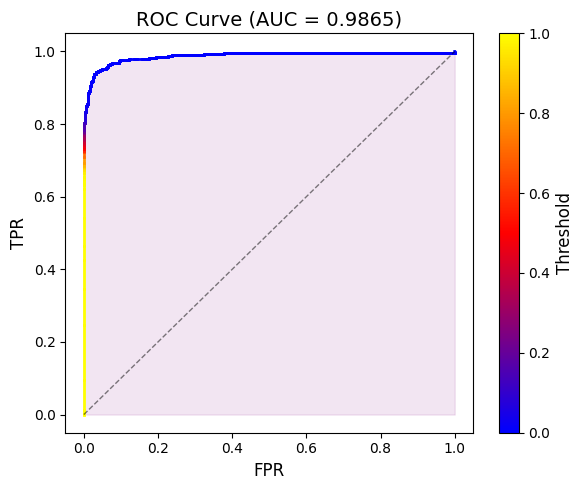

In [7]:
plot_roc(y_test, y_pred_proba, outputdir = "../../mlid-book/resources/ch2/ch2-fig9.png")

In [8]:
logit = LogisticRegression(random_state=10)
logit.fit(X_train, y_train)

y_logit_proba = logit.predict_proba(X_test)[:,1]

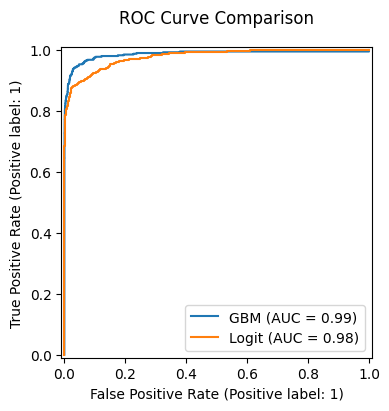

In [9]:
# Plot both ROC curves on the same axes

from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(4, 6))

ax = plt.gca()
RocCurveDisplay.from_predictions(y_test, y_pred_proba, name="GBM", ax=ax)
RocCurveDisplay.from_predictions(y_test, y_logit_proba, name="Logit", ax=ax)

ax.set_title("ROC Curve Comparison", y=1.05)
plt.tight_layout()
plt.savefig("../../mlid-book/resources/ch2/ch2-fig10.png", dpi=150)
plt.show()

In [10]:
from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score,
)

def plot_pr_curve(y, probs, color_area=True, outputdir=None):

    precision, recall, thresholds = precision_recall_curve(y, probs)
    auc_score = average_precision_score(y, probs)

    thresholds_clipped = np.clip(thresholds, 0, 1)
    
    blue_red = LinearSegmentedColormap.from_list("blue_red_yellow", ["blue", "red", "yellow"])

    fig, ax = plt.subplots(figsize=(7, 6))
    
    for i in range(len(precision) - 1):
        ax.plot(
            recall[i:i+2], precision[i:i+2],
            color=blue_red(thresholds_clipped[i]),
            lw=2
        )
    
    sm = cm.ScalarMappable(cmap=blue_red, norm=plt.Normalize(vmin=0, vmax=1))
    sm.set_array([])
    if color_area is True:
        ax.fill_between(recall, precision, alpha=0.1, color="purple")
    cbar = plt.colorbar(sm, ax=ax)
    cbar.set_label("Threshold", fontsize=12)
    
    ax.plot([0, 1], [np.mean(y), np.mean(y)], "k--", lw=1, alpha=0.5)
    
    ax.set_xlabel("Recall", fontsize=12)
    ax.set_ylabel("Precision", fontsize=12)
    ax.set_title(f"Precision-Recall Curve (AUC = {auc_score:.4f})", fontsize=14)
    
    plt.tight_layout()
    if outputdir is not None:
        plt.savefig(outputdir, dpi=300, bbox_inches="tight")
    plt.show()

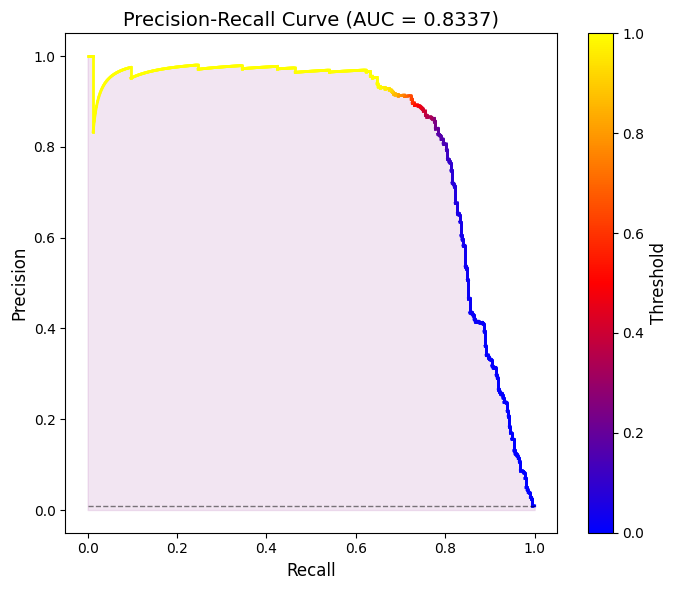

In [11]:
plot_pr_curve(y_test, y_pred_proba, color_area=True, outputdir="../../mlid-book/resources/ch2/ch2-fig14.png")

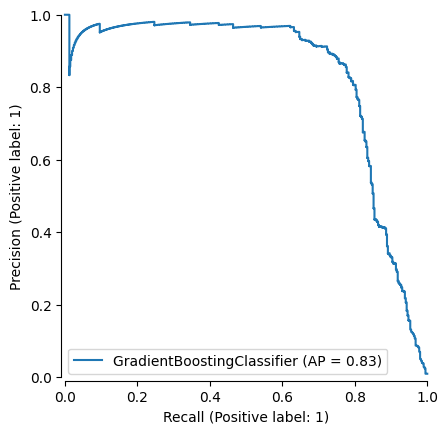

In [12]:
# Can also be done with sklearn
from sklearn.metrics import PrecisionRecallDisplay

display = PrecisionRecallDisplay.from_estimator(
    gbm, X_test, y_test, despine=True
)

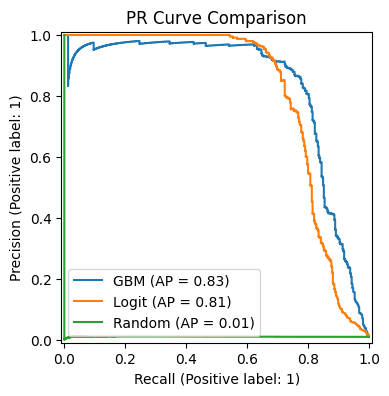

In [13]:
from sklearn.linear_model import LogisticRegression

logit = LogisticRegression(random_state=10, max_iter=100)
logit.fit(X_train, y_train)

y_logit_proba = logit.predict_proba(X_test)[:,1]

fig, ax = plt.subplots(figsize=(4, 6))

ax = plt.gca()
PrecisionRecallDisplay.from_predictions(y_test, y_pred_proba, name="GBM", ax=ax)
PrecisionRecallDisplay.from_predictions(y_test, y_logit_proba, name="Logit", ax=ax)
PrecisionRecallDisplay.from_predictions(y_test, np.random.uniform(0, 1, size=len(y_test)), name="Random", ax=ax)


ax.set_title("PR Curve Comparison")
plt.tight_layout()
plt.savefig("../../mlid-book/resources/ch2/ch2-fig15.png", dpi=150)
plt.show()